# Работа с временными рядами

# Разделим данные на обучающую и тестовую выборки

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('train.csv')
data

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
...,...,...,...,...
912995,2017-12-27,10,50,63
912996,2017-12-28,10,50,59
912997,2017-12-29,10,50,74
912998,2017-12-30,10,50,62


In [ ]:
df = data[data['store']==1]
df = df[df['item']==1].reset_index(drop=True)
df.drop(columns=['store', 'item'], inplace=True)
df

,date,sales
0,2013-01-01,13
1,2013-01-02,11
2,2013-01-03,14
3,2013-01-04,13
4,2013-01-05,10
...,...,...
1821,2017-12-27,14
1822,2017-12-28,19
1823,2017-12-29,15
1824,2017-12-30,27


In [ ]:
data_time = pd.to_datetime(df['date'])
data_time

,date
0,2013-01-01
1,2013-01-02
2,2013-01-03
3,2013-01-04
4,2013-01-05
...,...
1821,2017-12-27
1822,2017-12-28
1823,2017-12-29
1824,2017-12-30


In [ ]:
df['date'] = data_time

In [ ]:
train_data = df[df['date'].dt.year != 2017].reset_index(drop=True)
test_data = df[df['date'].dt.year == 2017].reset_index(drop=True)
display(train_data, test_data)

,date,sales
0,2013-01-01,13
1,2013-01-02,11
2,2013-01-03,14
3,2013-01-04,13
4,2013-01-05,10
...,...,...
1456,2016-12-27,10
1457,2016-12-28,16
1458,2016-12-29,21
1459,2016-12-30,24


,date,sales
0,2017-01-01,19
1,2017-01-02,15
2,2017-01-03,10
3,2017-01-04,16
4,2017-01-05,14
...,...,...
360,2017-12-27,14
361,2017-12-28,19
362,2017-12-29,15
363,2017-12-30,27


In [ ]:
X_train = train_data['date']
Y_train = train_data['sales']
X_test = test_data['date']
Y_test = test_data['sales']

# Визуализируем временной ряд

In [ ]:
import matplotlib.pyplot as plt

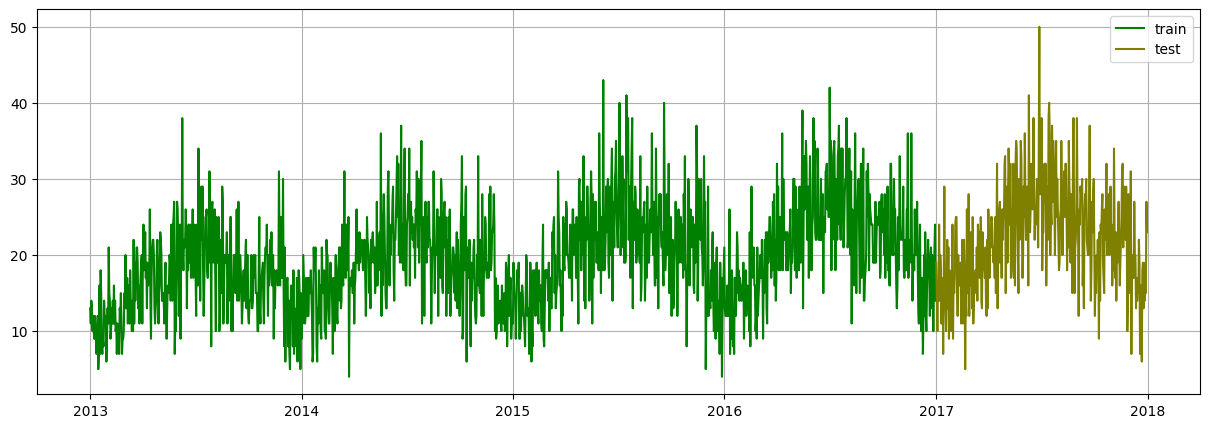

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(X_train, Y_train, color='green', label='train')
plt.plot(X_test, Y_test, color='olive', label='test')
plt.legend(loc='best')
plt.grid(True)
plt.show()



---



**Повышение**
- середина года


**Понижение**
- начало года
- конец года

# Тренд, сезон, автокорреляция

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL

In [ ]:
try_data = train_data.set_index('date')
try_data

,sales
date,
2013-01-01,13
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10
...,...
2016-12-27,10
2016-12-28,16
2016-12-29,21


This is a naive decomposition. More sophisticated methods should be preferred.

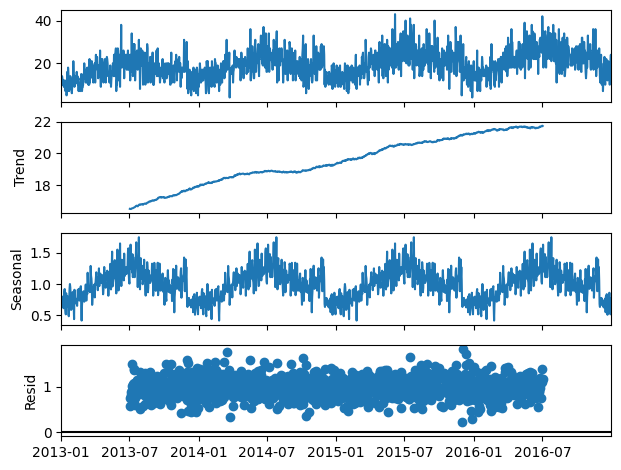

In [ ]:
sd = seasonal_decompose(try_data, period=365, model='multiplicative')
sd.plot()
plt.show()

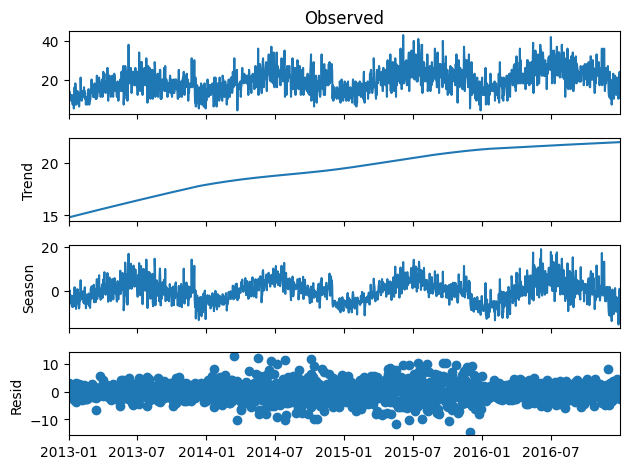

In [ ]:
stl = STL(try_data, period=365)
fit_stl = stl.fit()
fit_stl.plot()
plt.show()

In [ ]:
#res.config

*   **График тренда:** Показывает долгосрочные изменения в данных.
    - Если тренд показывает устойчивый рост, это указывает на долгосрочное увеличение значений временного ряда.

*   **График сезонности:** Показывает повторяющиеся колебания в данных.
    - Если сезонность показывает повторяющиеся пики и спады, это указывает на наличие сезонных эффектов в данных.

*   **График остатков:** Показывает случайные колебания в данных. (Остатки представляют собой случайные колебания в данных)
    - Если остатки имеют большую амплитуду, это указывает на высокую волатильность или наличие аномалий в данных.
    - Если остатки имеют малую амплитуду, это указывает на стабильность данных после учета тренда и сезонности.




---



---



---



In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

насколько сильно текущие значения временного ряда зависят от его прошлых значений

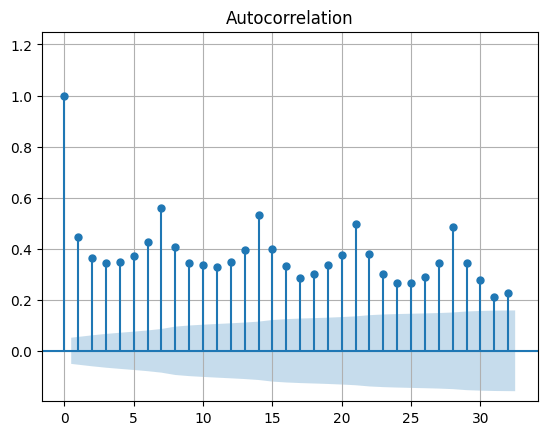

In [ ]:
plot_acf(try_data, auto_ylims=True)
plt.grid(True)
plt.show()

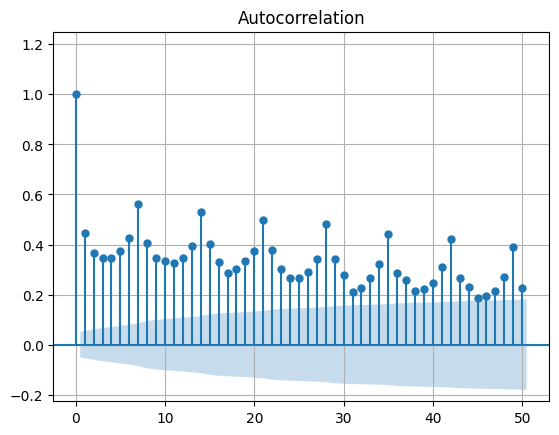

In [ ]:
plot_acf(try_data, lags=50, auto_ylims=True)
plt.grid(True)
plt.show()

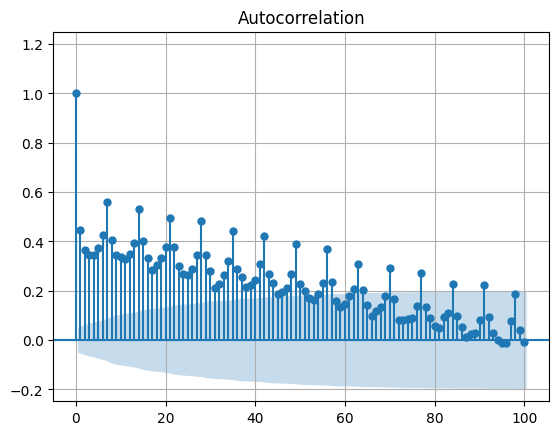

In [ ]:
plot_acf(try_data, lags=100, auto_ylims=True)
plt.grid(True)
plt.show()

**Лаги**
- **Лаг 1:** Если значение автокорреляции для лага 1 значительно отлично от нуля, это указывает на сильную зависимость текущего значения от предыдущего значения.
- **Лаг 2 и далее:** Если значения автокорреляции для более высоких лагов также значительны, это указывает на более длительные временные зависимости.

**Автокорреляционные коэффициенты**
- **Значительные коэффициенты:** Если автокорреляционные коэффициенты выходят за пределы конфиденциального интервала, это указывает на статистическую значимость корреляции.
- **Незначительные коэффициенты: Если автокорреляционные коэффициенты находятся в пределах конфиден**циального интервала, это указывает на отсутствие значимой корреляции для данного лага.



---



---



# Экспоненциальное сглаживание

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing as ES
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [ ]:
model = ES(
    Y_train,
    seasonal='mul',
    seasonal_periods=365,
    trend='add'
).fit()

In [ ]:
print(model.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                    sales   No. Observations:                 1461
Model:             ExponentialSmoothing   SSE                          28051.874
Optimized:                         True   AIC                           5055.159
Trend:                         Additive   BIC                           7006.016
Seasonal:                Multiplicative   AICC                          5308.625
Seasonal Periods:                   365   Date:                 Mon, 16 Dec 2024
Box-Cox:                          False   Time:                         02:25:43
Box-Cox Coeff.:                    None                                         
                           coeff                 code              optimized      
----------------------------------------------------------------------------------
smoothing_level                0.0048486                alpha                 True
smoothing_trend       

In [ ]:
steps = 730
forecast = model.forecast(steps=steps)

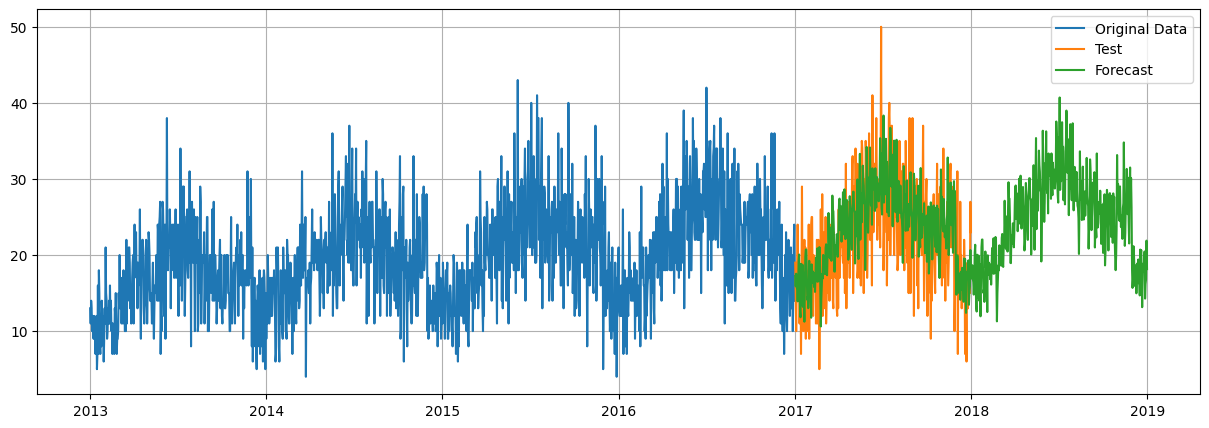

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(X_train ,Y_train, label='Original Data')
plt.plot(X_test, Y_test, label='Test')
plt.plot(
    pd.date_range(
        start=X_test[0],
        periods=steps
    ),
    forecast,
    label='Forecast'
)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
results = {}
results['ES'] = {
    'MSE': mean_squared_error(Y_test, forecast[:len(Y_test)]),
    'MAE': mean_absolute_error(Y_test, forecast[:len(Y_test)]),
    'MAPE': mean_absolute_percentage_error(Y_test, forecast[:len(Y_test)])
}

print(results['ES'])

{'MSE': 48.35510175497184, 'MAE': 5.382962413112105, 'MAPE': 0.2926088016841605}


# Градиентный бустинг

In [ ]:
def get_cats(df, add_sales):
  lag_cat = pd.DataFrame()
  if add_sales == 'y':
    lag_cat['sales'] = df['sales']
  lag_cat['year'] = df['date'].dt.year
  lag_cat['month'] = df['date'].dt.month
  lag_cat['day'] = df['date'].dt.day
  lag_cat['quarter'] = df['date'].dt.quarter
  lag_cat['weekday'] = df['date'].dt.weekday
  lag_cat['dayofyear'] = df['date'].dt.dayofyear

  weekend = []
  for i in lag_cat['weekday']:
    if i == 5 or i == 6:
      weekend.append(1)
    else:
      weekend.append(0)
  lag_cat['weekend'] = weekend

  lag_cat['lag_1'] = df['sales'].shift(1)
  lag_cat['lag_2'] = df['sales'].shift(2)
  lag_cat['lag_3'] = df['sales'].shift(3)
  lag_cat['lag_4'] = df['sales'].shift(4)
  lag_cat['lag_5'] = df['sales'].shift(5)
  lag_cat['lag_6'] = df['sales'].shift(6)
  lag_cat['lag_7'] = df['sales'].shift(7)

  lag_cat = lag_cat.dropna().reset_index(drop=True)

  return lag_cat

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor as GBR

In [ ]:
gbr = GBR().fit(
    get_cats(train_data, 'n'),
    get_cats(train_data, 'y')['sales']
)

In [ ]:
year_dates = pd.date_range(
    start=test_data.tail(1).values[0][0],
    periods=366
)[1:]

In [ ]:
# предсказания для теста
n_samp = 7
base = train_data.tail(n_samp).reset_index(drop=True)
pred_2017 = pd.DataFrame(columns=['date', 'sales'])
n = 0
for date in test_data['date']:
  base.loc[n_samp] = [date, None]
  pred = int(gbr.predict(get_cats(base, 'n'))[0])
  pred_2017.loc[n] = [date, pred]

  base['sales'][n_samp] = pred
  base = base.tail(n_samp).reset_index(drop=True)
  n += 1

In [ ]:
# предсказания на год вперёд
base = pred_2017.tail(n_samp).reset_index(drop=True)
new_year = pd.DataFrame(columns=['date', 'sales'])
n = 0
for date in year_dates:
  base.loc[n_samp] = [date, None]
  pred = int(gbr.predict(get_cats(base, 'n'))[0])
  new_year.loc[n] = [date, pred]

  base['sales'][n_samp] = pred
  base = base.tail(n_samp).reset_index(drop=True)
  n += 1

In [ ]:
preds = pd.concat([pred_2017, new_year], ignore_index=True)

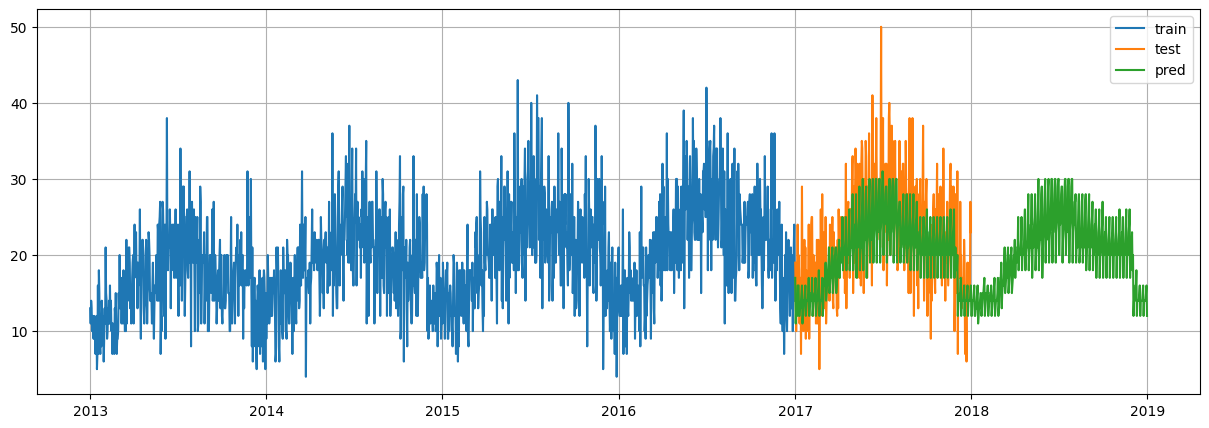

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(
    train_data['date'],
    train_data['sales'],
    #color='green',
    label='train'
)
plt.plot(
    test_data['date'],
    test_data['sales'],
    #color='olive',
    label='test'
)
plt.plot(
    preds['date'],
    preds['sales'],
    label='pred'
)
plt.legend(loc='best')
plt.grid(True)
plt.show()

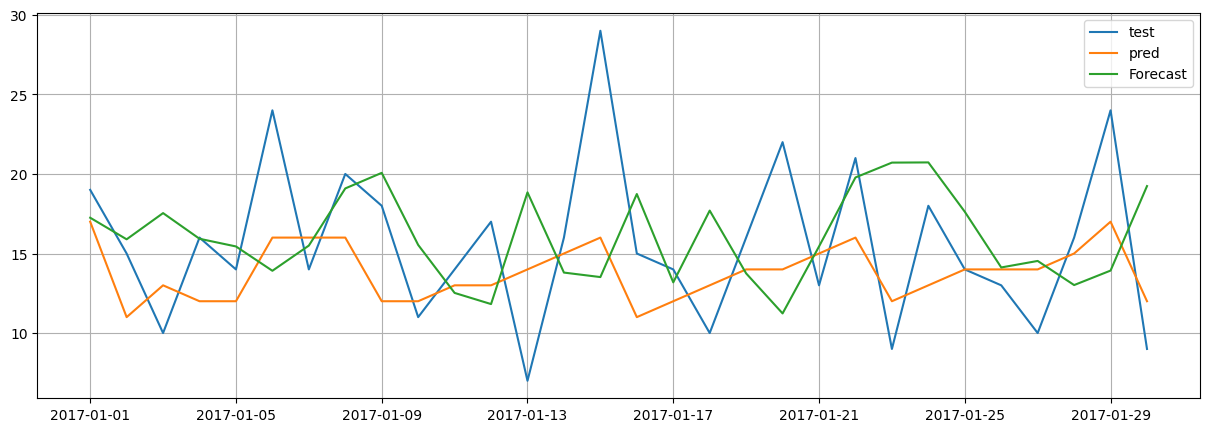

In [ ]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_data['date'][:30],
    test_data['sales'][:30],
    #color='olive',
    label='test'
)
plt.plot(
    preds['date'][:30],
    preds['sales'][:30],
    label='pred'
)


plt.plot(
    pd.date_range(
        start=X_test[0],
        periods=steps
    )[:30],
    forecast[:30],
    label='Forecast'
)
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
results['GB'] = {
    'MSE': mean_squared_error(Y_test, preds['sales'][:len(Y_test)]),
    'MAE': mean_absolute_error(Y_test, preds['sales'][:len(Y_test)]),
    'MAPE': mean_absolute_percentage_error(Y_test, preds['sales'][:len(Y_test)])
}

print(results['GB'])

{'MSE': 26.956164383561642, 'MAE': 4.073972602739726, 'MAPE': 0.1916890318403333}


# Общие выводы

In [ ]:
pd.DataFrame(results)

,ES,GB
MSE,48.355102,25.441096
MAE,5.382962,3.983562
MAPE,0.292609,0.194504


Коротко: градиентный бустинг показал меньшую ошибку на тесте, чем экспоненциальное сглаживание.